# 0 Dataset Prep

In [2]:
from datasets import load_dataset

# Load the wikitext-2-v1 dataset
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-v1")

# Access the training split
train_data = dataset['train']

/Users/almas/Downloads/Documents/Projects/VSCode_Projects/NLP/HW1/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Module 1

## TODO 1.1

In [3]:
from collections import Counter
import numpy as np

docs = [d["text"] for d in train_data if d["text"].strip() != ""]

vocab = {}
word_counts = Counter()

for doc in docs: # global word counts
    word_counts.update(doc.split())

for i, word in enumerate(word_counts.keys()): # provide index for each word
    vocab[word] = i

C = np.zeros((len(vocab), len(docs)))

for j, doc in enumerate(docs):
    words = doc.split()
    for word in words:
        if word in vocab:
            i = vocab[word]
            C[i, j] += 1

## TODO 1.2

In [4]:
df = np.array((C > 0).sum(axis=1)).flatten()

N = C.shape[1]
idf = np.log(N / df)

C_tfidf = C*idf[:, np.newaxis]

## TODO 1.3

In [5]:
from sklearn.decomposition import TruncatedSVD

k = 100
svd = TruncatedSVD(n_components=k, random_state=42)
W = svd.fit_transform(C_tfidf)
sigma = svd.singular_values_
Vt = svd.components_

## Scree Plot

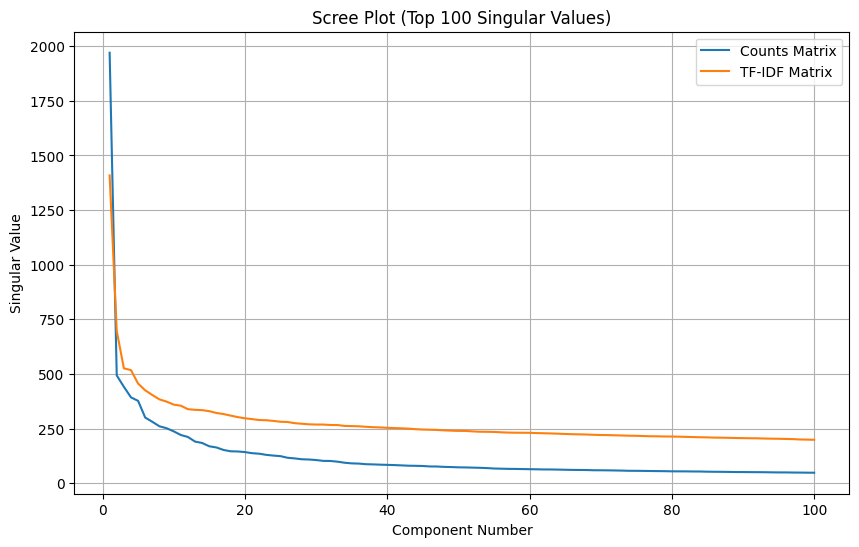

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

k = 100

# --- For raw count matrix C ---
svd_counts = TruncatedSVD(n_components=k, random_state=42)
svd_counts.fit(C)
singular_values_counts = svd_counts.singular_values_

# --- For TF-IDF matrix ---
svd_tfidf = TruncatedSVD(n_components=k, random_state=42)
svd_tfidf.fit(C_tfidf)
singular_values_tfidf = svd_tfidf.singular_values_

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.plot(range(1, k+1), singular_values_counts, label="Counts Matrix")
plt.plot(range(1, k+1), singular_values_tfidf, label="TF-IDF Matrix")

plt.xlabel("Component Number")
plt.ylabel("Singular Value")
plt.title("Scree Plot (Top 100 Singular Values)")
plt.legend()
plt.grid(True)

plt.show()

## Analysis
Keeping the largest singular values gives the best low-rank approximation of the original matrix. If we truncate the SVD and keep only the top k singular values, we form $C_k = U_k \Sigma_k V_k^\top$, which minimizes the reconstruction error $\|C - C_k\|_F$ among all rank-k matrices. By the Frobenius norm criterion from Lecture 04, Slide 25, the better approximation is the one with the smaller error norm, so we keep the singular values that reduce this error the most. The largest singular values capture the most important structure in the data, while the smaller ones contribute much less and often reflect noise or less informative patterns. Therefore, discarding the smaller singular values reduces dimensionality while preserving most of the meaningful information.

# Module 2

## TODO 2.1

In [ ]:
import fasttext

docs = [d["text"] for d in train_data if d["text"].strip() != ""]

with open("train.txt", "w") as f:
    for doc in docs:
        f.write(doc + "\n")
    
model = fasttext.train_unsupervised("train.txt", "skipgram")

Read 2M words
Number of words:  23380
Number of labels: 0
Progress: 100.0% words/sec/thread:  108838 lr:  0.000000 avg.loss:  2.027622 ETA:   0h 0m 0s


## TODO 2.2

In [8]:
models = {}

for dim in [50, 100, 300]:
    name = f"dim_{dim}"
    models[name] = fasttext.train_unsupervised(input="train.txt", model="skipgram", dim=dim, ws=5, lr=0.05)

for ws in [2, 5, 10]:
    name = f"ws_{ws}"
    models[name] = fasttext.train_unsupervised(input="train.txt", model="skipgram", dim=100, ws=ws, lr=0.05)

for lr in [0.01, 0.05, 0.1]:
    name = f"lr_{lr}"
    models[name] = fasttext.train_unsupervised(input="train.txt", model="skipgram", dim=100, ws=5, lr=lr)


Read 2M words
Number of words:  23380
Number of labels: 0
Progress: 100.0% words/sec/thread:  164187 lr:  0.000000 avg.loss:  2.039798 ETA:   0h 0m 0s
Read 2M words
Number of words:  23380
Number of labels: 0
Progress: 100.0% words/sec/thread:  109825 lr:  0.000000 avg.loss:  2.026703 ETA:   0h 0m 0s
Read 2M words
Number of words:  23380
Number of labels: 0
Progress: 100.0% words/sec/thread:   45766 lr:  0.000000 avg.loss:  2.028753 ETA:   0h 0m 0s0.029737 avg.loss:  2.057779 ETA:   0h 0m15s
Read 2M words
Number of words:  23380
Number of labels: 0
Progress: 100.0% words/sec/thread:  194266 lr:  0.000000 avg.loss:  2.129535 ETA:   0h 0m 0s
Read 2M words
Number of words:  23380
Number of labels: 0
Progress: 100.0% words/sec/thread:  100198 lr:  0.000000 avg.loss:  2.030160 ETA:   0h 0m 0s
Read 2M words
Number of words:  23380
Number of labels: 0
Progress: 100.0% words/sec/thread:   61385 lr:  0.000000 avg.loss:  1.902223 ETA:   0h 0m 0s
Read 2M words
Number of words:  23380
Number of la

## TODO 2.3

In [10]:
target_words = ["king", "queen", "city", "computer", "science"]

def cosine_similarity(vec1, vec2):
    numerator = np.dot(vec1, vec2)
    denominator = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    if denominator == 0:
        return 0.0
    return numerator / denominator

for model_name, model in models.items():
    print(f"\nModel: {model_name}")
    
    for target in target_words:
        target_vector = model.get_word_vector(target)
        similarities = []
        
        for word in model.words:
            if word != target:
                word_vector = model.get_word_vector(word)
                sim = cosine_similarity(target_vector, word_vector)
                similarities.append((word, sim))
        
        similarities.sort(key=lambda x: x[1], reverse=True)
        top_5 = similarities[:5]
        
        print(f"\nTarget word: {target}")
        for neighbor, sim in top_5:
            print(f"{neighbor}: {sim}")


Model: dim_50

Target word: king
King: 0.8319805264472961
Qing: 0.8056011199951172
Odaenathus: 0.8055121302604675
reigning: 0.7988498210906982
Taking: 0.7825345396995544

Target word: queen
Menkauhor: 0.8154054880142212
Esarhaddon: 0.813814103603363
queens: 0.8082977533340454
Jesus: 0.7948119640350342
throne: 0.7929924726486206

Target word: city
residential: 0.804125189781189
community: 0.7981953024864197
neighborhood: 0.7936812043190002
Haifa: 0.7916344404220581
neighborhoods: 0.7893450856208801

Target word: computer
computers: 0.9333083033561707
computing: 0.8480169773101807
electronics: 0.8117523789405823
mechanics: 0.8098180890083313
technologies: 0.8035174012184143

Target word: science
sciences: 0.9152582883834839
conscience: 0.8818824887275696
scientist: 0.8156182765960693
typewriter: 0.7839230895042419
scientific: 0.7790668606758118

Model: dim_100

Target word: king
Qing: 0.8098981380462646
King: 0.7882824540138245
Taking: 0.7783011198043823
Jing: 0.7700607776641846
asking:

## Qualitative Neighborhood Analysis

### Shift Due to Hyperparameters

Changing the embedding dimension had some effect, but the neighbors were fairly consistent across `dim=50`, `dim=100`, and `dim=300`, especially for words like computer and science, which consistently returned related terms such as computers, computing, and sciences. This suggests that dimension affected refinement more than the overall type of similarity learned.

The context window had a stronger impact. With a small window (`ws=2`), several neighbors were noisy or based more on surface patterns than meaning, while larger windows (`ws=5` and `ws=10`) produced more semantically meaningful results. For example, city shifted toward words like municipality and municipal, and computer shifted toward computing, computation, and computational.

The learning rate produced the biggest difference. At `lr=0.01`, many neighbors were clearly poor matches, suggesting the model did not train well enough. At `lr=0.05`, the neighbors were much more coherent and meaningful, while `lr=0.1` still performed reasonably well but was slightly less stable. Overall, the context window and learning rate had the strongest effect on word similarity, while embedding dimension had a smaller effect.

### Model: dim_50

- **king**
  - King: 0.8319
  - Qing: 0.8056
  - Odaenathus: 0.8055
  - reigning: 0.7988
  - Taking: 0.7825

- **queen**
  - Menkauhor: 0.8154
  - Esarhaddon: 0.8138
  - queens: 0.8083
  - Jesus: 0.7948
  - throne: 0.7930

- **city**
  - residential: 0.8041
  - community: 0.7982
  - neighborhood: 0.7937
  - Haifa: 0.7916
  - neighborhoods: 0.7893

- **computer**
  - computers: 0.9333
  - computing: 0.8480
  - electronics: 0.8118
  - mechanics: 0.8098
  - technologies: 0.8035

- **science**
  - sciences: 0.9153
  - conscience: 0.8819
  - scientist: 0.8156
  - typewriter: 0.7839
  - scientific: 0.7791


### Model: dim_100

- **king**
  - Qing: 0.8099
  - King: 0.7883
  - Taking: 0.7783
  - Jing: 0.7701
  - asking: 0.7667

- **queen**
  - queens: 0.7855
  - Queen: 0.7718
  - Menkauhor: 0.7544
  - patriarchal: 0.7481
  - keen: 0.7426

- **city**
  - tenacity: 0.7336
  - municipality: 0.7157
  - community: 0.7073
  - Municipality: 0.7065
  - neighborhoods: 0.6840

- **computer**
  - computers: 0.9048
  - computing: 0.8200
  - mechanics: 0.7574
  - mechanic: 0.7421
  - computation: 0.7365

- **science**
  - sciences: 0.9021
  - conscience: 0.8725
  - Science: 0.7899
  - scientist: 0.7480
  - patience: 0.7261


### Model: dim_300

- **king**
  - Qing: 0.8129
  - Taking: 0.7996
  - King: 0.7831
  - Viking: 0.7700
  - Jing: 0.7696

- **queen**
  - queens: 0.7813
  - Queen: 0.7446
  - Esarhaddon: 0.7407
  - Menkauhor: 0.7315
  - patriarchal: 0.7305

- **city**
  - tenacity: 0.7365
  - municipality: 0.7153
  - Municipality: 0.6975
  - community: 0.6674
  - immunity: 0.6552

- **computer**
  - computers: 0.8833
  - computing: 0.8033
  - mechanics: 0.7314
  - Computer: 0.7271
  - computation: 0.7145

- **science**
  - sciences: 0.8894
  - conscience: 0.8646
  - Science: 0.7943
  - patience: 0.7391
  - obedience: 0.7373


### Model: ws_2

- **king**
  - Viking: 0.8898
  - Qing: 0.8735
  - Jing: 0.8655
  - King: 0.8652
  - Taking: 0.8598

- **queen**
  - Oden: 0.8459
  - Goeben: 0.8222
  - Weyden: 0.8220
  - Ledden: 0.8188
  - Amlaíb: 0.8029

- **city**
  - tenacity: 0.8214
  - municipality: 0.7894
  - immunity: 0.7866
  - laity: 0.7763
  - vicinity: 0.7690

- **computer**
  - computers: 0.8268
  - compulsory: 0.8244
  - compatibility: 0.7984
  - compact: 0.7819
  - comprehend: 0.7804

- **science**
  - sciences: 0.8880
  - conscience: 0.8874
  - obedience: 0.8392
  - patience: 0.8267
  - excellence: 0.8139


### Model: ws_5

- **king**
  - Qing: 0.8056
  - King: 0.7823
  - Taking: 0.7775
  - asking: 0.7537
  - Jing: 0.7528

- **queen**
  - queens: 0.8053
  - Menkauhor: 0.7877
  - patriarchal: 0.7683
  - Queen: 0.7537
  - keen: 0.7507

- **city**
  - municipality: 0.7410
  - Municipality: 0.7293
  - tenacity: 0.7232
  - community: 0.7013
  - municipal: 0.6992

- **computer**
  - computers: 0.8860
  - computing: 0.8329
  - mechanics: 0.7824
  - mechanic: 0.7433
  - Computer: 0.7388

- **science**
  - sciences: 0.8954
  - conscience: 0.8718
  - Science: 0.7750
  - scientist: 0.7321
  - obedience: 0.7170


### Model: ws_10

- **king**
  - King: 0.8136
  - Qing: 0.7656
  - Taking: 0.7572
  - kings: 0.7261
  - liking: 0.7020

- **queen**
  - queens: 0.8481
  - Esarhaddon: 0.7756
  - Zabibe: 0.7580
  - Patriarchal: 0.7577
  - martyr: 0.7508

- **city**
  - Municipality: 0.7478
  - municipality: 0.7301
  - municipal: 0.7006
  - municipalities: 0.6982
  - Municipal: 0.6929

- **computer**
  - computers: 0.9069
  - computing: 0.8598
  - Computer: 0.8087
  - computation: 0.7947
  - computational: 0.7229

- **science**
  - sciences: 0.9112
  - conscience: 0.8422
  - Science: 0.7636
  - scientist: 0.7181
  - Sciences: 0.6852

### Model: lr_0.01

- **king**
  - hiking: 0.9775
  - asking: 0.9766
  - being: 0.9752
  - Qing: 0.9740
  - ing: 0.9719

- **queen**
  - erroneously: 0.9977
  - Oden: 0.9976
  - unanimously: 0.9970
  - garden: 0.9964
  - lady: 0.9961

- **city**
  - centre: 0.9843
  - central: 0.9818
  - county: 0.9817
  - port: 0.9803
  - centric: 0.9802

- **computer**
  - fatigue: 0.9931
  - comparison: 0.9931
  - precursor: 0.9930
  - maritime: 0.9928
  - prosecutor: 0.9927

- **science**
  - politics: 0.9937
  - scientist: 0.9901
  - ideology: 0.9892
  - Personality: 0.9888
  - theology: 0.9874


### Model: lr_0.05

- **king**
  - King: 0.7791
  - Qing: 0.7761
  - Taking: 0.7593
  - kings: 0.7546
  - Viking: 0.7527

- **queen**
  - queens: 0.7813
  - Queen: 0.7549
  - patriarchal: 0.7503
  - Esarhaddon: 0.7474
  - throne: 0.7436

- **city**
  - municipality: 0.7268
  - Municipality: 0.7199
  - tenacity: 0.6989
  - residential: 0.6891
  - neighborhoods: 0.6882

- **computer**
  - computers: 0.9098
  - computing: 0.8203
  - mechanics: 0.7773
  - technologies: 0.7764
  - computation: 0.7507

- **science**
  - sciences: 0.8905
  - conscience: 0.8772
  - Science: 0.7840
  - scientist: 0.7466
  - obedience: 0.7272


### Model: lr_0.1

- **king**
  - coronation: 0.7048
  - King: 0.6943
  - Qing: 0.6738
  - kings: 0.6585
  - reigning: 0.6387

- **queen**
  - queens: 0.8023
  - martyr: 0.6610
  - knight: 0.6322
  - patriarchal: 0.6253
  - warrior: 0.6087

- **city**
  - town: 0.6691
  - tourist: 0.6488
  - metropolitan: 0.6420
  - residential: 0.6403
  - Bridgwater: 0.6396

- **computer**
  - computers: 0.9333
  - computing: 0.8613
  - Computer: 0.8024
  - computation: 0.7698
  - computational: 0.7124

- **science**
  - sciences: 0.8915
  - conscience: 0.7767
  - fiction: 0.7143
  - Science: 0.6710
  - scientist: 0.6669